In [220]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch
import shap

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
pp = Preprocessor()

In [222]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [288]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [289]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 18533
count    18533.000000
mean        31.338261
std         83.872808
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [290]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69230.027576,0.000000e+00,0.000000e+00
STRADA,9.487686,9.188342,9.375162,8.935217,9.189309,40043.610021,0.000000e+00,0.000000e+00
PIK3R6,4.953432,5.001262,5.058186,5.178365,5.037032,4016.626570,0.000000e+00,0.000000e+00
SAMD9,9.454183,9.385430,9.352988,9.353712,9.378219,8472.898002,0.000000e+00,0.000000e+00
YME1L1,12.087980,11.915021,11.968255,12.079383,11.957913,100013.934220,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
TMEM229A,0.349584,0.207897,0.218256,0.103054,0.198622,12.900652,1.670292e-10,1.670652e-10
PAGE2,0.285851,0.312058,0.459990,0.754457,0.406439,12.836736,1.889000e-10,1.889306e-10
SLC28A2,0.355432,0.277010,0.242954,0.086340,0.243943,12.577395,3.111464e-10,3.111800e-10
FMR1NB,0.084961,0.267415,0.215001,0.499620,0.289179,11.949205,1.040456e-09,1.040512e-09


In [328]:
N_GENES = 100
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma

X_scaled, durations, events, scaler = torch_preprocessing.get_data_set(60)

Genes before Treshold: 103
count    103.000000
mean       1.330097
std        6.002268
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       42.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 103


In [330]:
genes_expression = top_genes_limma

In [331]:
X_scaled.shape

(519, 100)

In [332]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [412]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [413]:
train_X.shape

torch.Size([415, 100])

Grid Search for the best Model

In [300]:
from itertools import product

param_grid = {
    "num_nodes": [[32], [16], [32,16], [32,32], [64,32]],
    "dropout": [0.0, 0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [64 ,128, 256],
}

grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [301]:
in_features = train_X.shape[1]
output_bias = False

best_score = -1
best_params = None

train_X = np.array(train_X)
train_durations = np.array(train_durations)
train_events = np.array(train_events).astype(bool)

val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes,dp,bn, lr, wd, batch_size  in grid:
    net = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=num_nodes,
        out_features=1,
        dropout=dp,
        output_bias=output_bias,
        batch_norm=bn,
        )
    
    model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=wd))
    
    model.optimizer.set_lr(lr)
    model.fit(
                input=train_X,
                target=(train_durations, train_events),
                epochs=100,
                verbose=False,
                val_data=(val_X, (val_durations, val_events)),
                val_batch_size=batch_size
            )
    
    model.net.eval()
    model.compute_baseline_hazards()
    surv = model.predict_surv_df(val_X)

    ev = EvalSurv(surv, val_durations, val_events)
    c_index = ev.concordance_td()
    if c_index > best_score:
                best_score = c_index
                best_params = (num_nodes, dp, bn, lr, wd, batch_size)

    

print(best_params, best_score)


([32, 16], 0.0, False, 0.0001, 0, 128) 0.9649122807017544


Training the Model

In [414]:

train_X = np.array(train_X)
train_durations = np.array(train_durations)
train_events = np.array(train_events).astype(bool)

in_features = train_X.shape[1]
output_bias = False

num_nodes = [32, 16]
out_features = 1
dropout = 0.2
batch_norm = False
lr = 0.005
weight_decay =  0.0001
batch_size = 256



net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


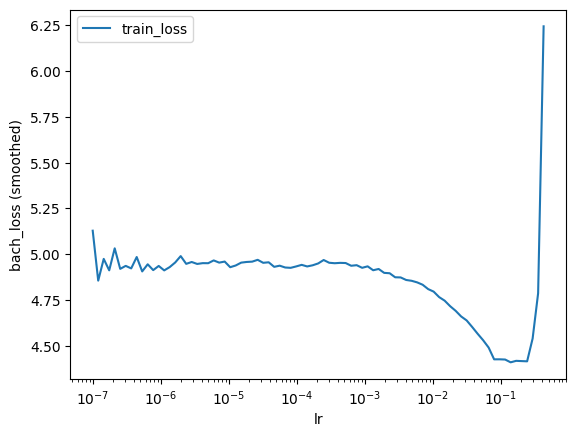

In [415]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [416]:
train_durations.shape

(415,)

In [417]:
model.optimizer.set_lr(lr)


In [418]:
epochs = 250
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [419]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 5.1130,	val_loss: 3.3644
1:	[0s / 0s],		train_loss: 4.5903,	val_loss: 3.2308
2:	[0s / 0s],		train_loss: 4.4608,	val_loss: 3.1441
3:	[0s / 0s],		train_loss: 4.3438,	val_loss: 3.0737
4:	[0s / 0s],		train_loss: 4.1439,	val_loss: 3.0031
5:	[0s / 0s],		train_loss: 3.9705,	val_loss: 2.9324
6:	[0s / 0s],		train_loss: 3.9530,	val_loss: 2.8728
7:	[0s / 0s],		train_loss: 3.8976,	val_loss: 2.8266
8:	[0s / 0s],		train_loss: 3.7836,	val_loss: 2.8039
9:	[0s / 0s],		train_loss: 3.4943,	val_loss: 2.7830
10:	[0s / 0s],		train_loss: 3.4661,	val_loss: 2.7541
11:	[0s / 0s],		train_loss: 3.3305,	val_loss: 2.7089
12:	[0s / 0s],		train_loss: 3.2638,	val_loss: 2.6462
13:	[0s / 0s],		train_loss: 3.0184,	val_loss: 2.5742
14:	[0s / 0s],		train_loss: 3.3587,	val_loss: 2.5165
15:	[0s / 0s],		train_loss: 3.1600,	val_loss: 2.5311
16:	[0s / 0s],		train_loss: 2.9136,	val_loss: 2.5667
17:	[0s / 0s],		train_loss: 2.8149,	val_loss: 2.6279
18:	[0s / 0s],		train_loss: 2.6442,	val_loss: 2.6905
19:

In [420]:
def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        out = model.net(x_tensor)
    return out.cpu().numpy().reshape(-1)


explainer_shap = shap.Explainer(model_predict, train_X, feature_names=genes_expression)


torch.Size([52, 100])

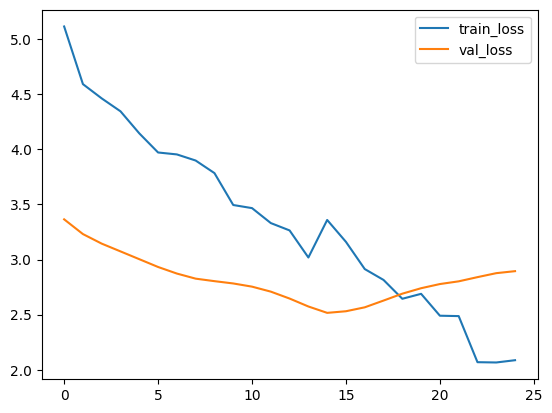

In [421]:
_ = log.plot()
val_X.shape

Log Likehood (The Loss)

In [422]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.516468

In [423]:
_ = model.compute_baseline_hazards()

In [424]:
surv = model.predict_surv_df(input=test_X)

In [425]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [426]:
risk_nn = model.net(test_X).flatten()

list_risk = []
for i in risk_nn:
    list_risk.append(i.item())


In [439]:
list_risk

[-4.216794013977051,
 -5.399074554443359,
 0.07457864284515381,
 -4.770530700683594,
 -0.6548991203308105,
 -4.5138750076293945,
 -0.34743908047676086,
 -1.4675054550170898,
 -2.257390022277832,
 -4.307929515838623,
 -4.223320960998535,
 0.0876699686050415,
 -1.791651964187622,
 -1.2829806804656982,
 -4.50039529800415,
 0.8329095840454102,
 -0.41755908727645874,
 -7.899841785430908,
 -1.441483974456787,
 0.9831709265708923,
 -0.6790995001792908,
 -3.0260815620422363,
 -2.8727335929870605,
 -6.83896541595459,
 -5.257829666137695,
 -3.548718214035034,
 -4.094570159912109,
 -0.9660990834236145,
 -1.2631406784057617,
 -1.3195642232894897,
 -3.1974716186523438,
 0.22833704948425293,
 -3.907867431640625,
 -3.015564203262329,
 -7.645623207092285,
 -1.7898781299591064,
 -4.299946308135986,
 -4.932286262512207,
 -1.4516046047210693,
 -0.34745797514915466,
 -2.4721407890319824,
 -6.053763389587402,
 0.06089332699775696,
 -0.4730677604675293,
 -1.25924813747406,
 -0.12006732821464539,
 -5.4843363

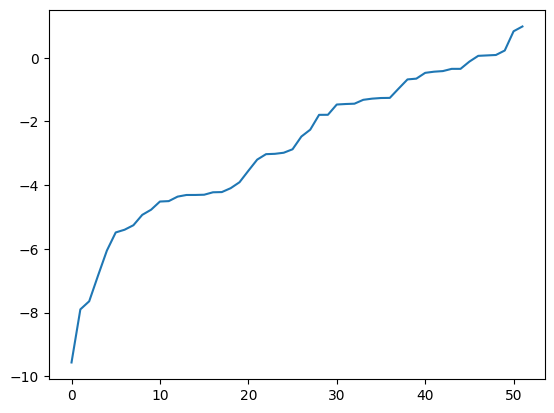

In [445]:

plt.plot(sorted(list_risk))


For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 18
For the time 24 the risk group is 11
For the time 36 the risk group is 5
For the time 48 the risk group is 2
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 23
For the time 24 the risk group is 14
For the time 36 the risk group is 10
For the time 48 the risk group is 7
For the time 60 the risk group is 0


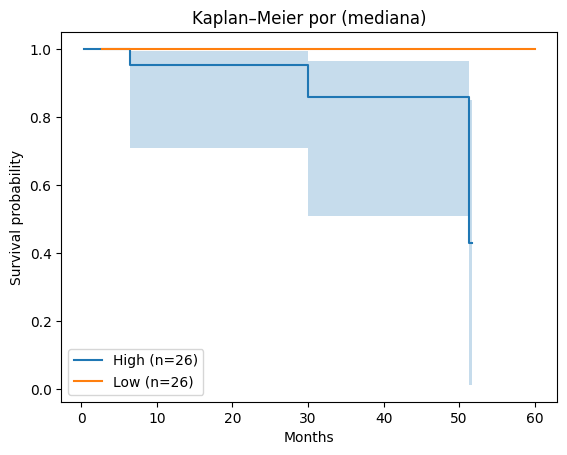

In [427]:
df = pd.DataFrame()

thr = np.median(list_risk)
df["group"] = np.where(risk_nn > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [428]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")



Log-rank: chi2=4.703, p=0.0301


Prediction of survival of the Patients

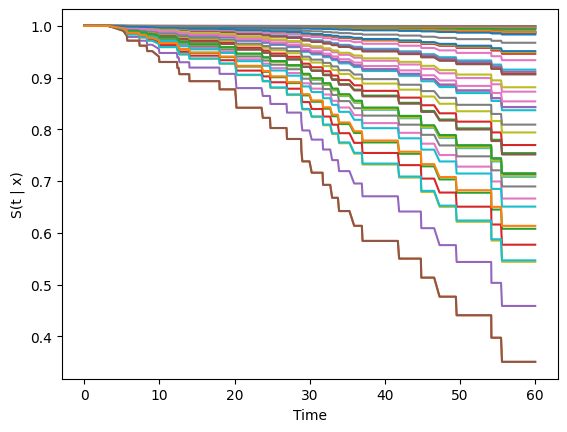

In [398]:
surv.iloc[:, :].plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

In [429]:
test_X = test_X.cpu().detach().numpy()
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [430]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [431]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.8888888888888888


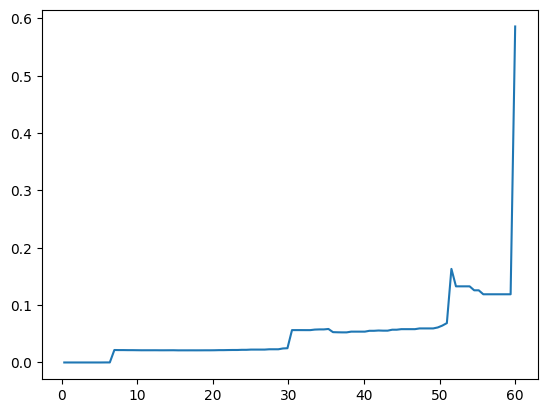

In [432]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [433]:
ev.integrated_brier_score(time_grid=time_grid)

0.049480852475765946

In [434]:
ev.integrated_nbll(time_grid)

0.15661838266664832

In [435]:
type(test_X)

numpy.ndarray

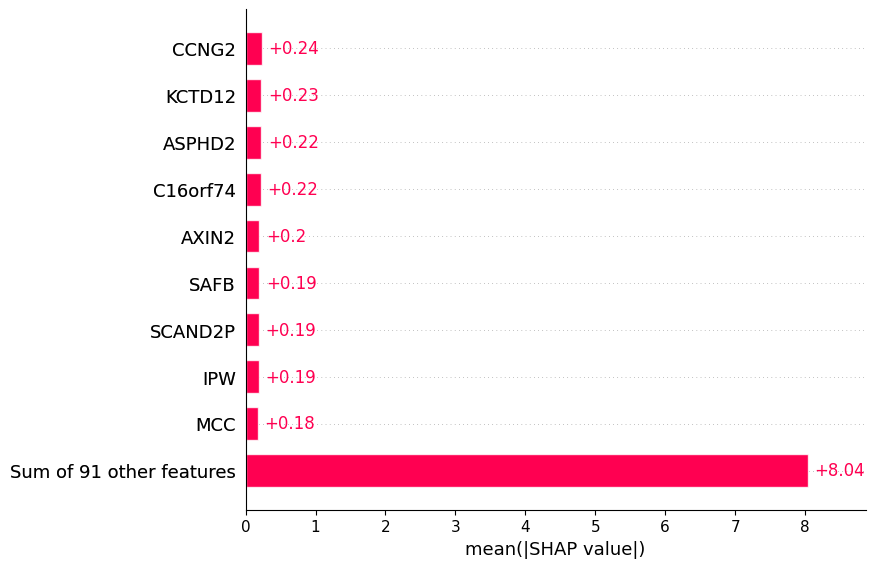

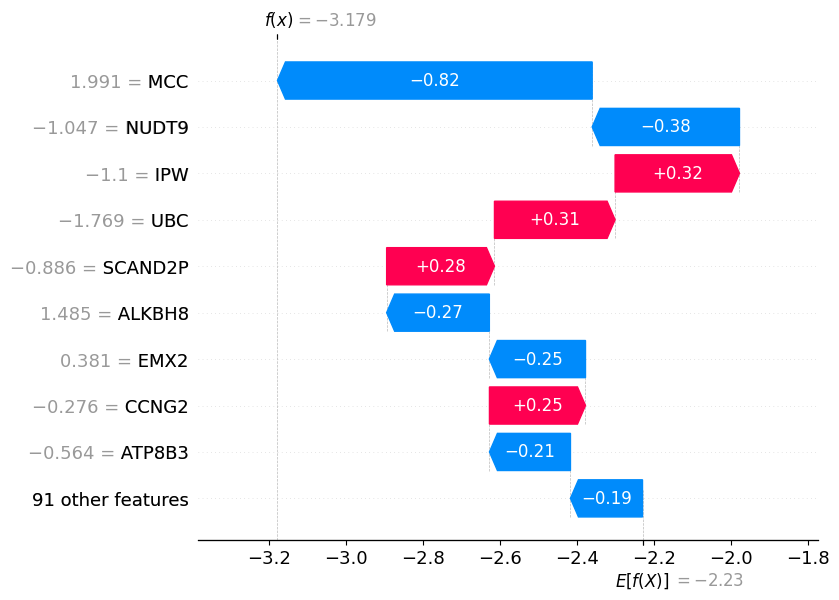

In [436]:
shap_values = explainer_shap(test_X)

shap.plots.bar(shap_values)
shap.plots.waterfall(shap_values[0])

The most important genes

In [407]:
mean_shap = np.abs(shap_values.values).mean(axis=0)

df_importance = pd.DataFrame({
    "gene": genes_expression,
    "importance": mean_shap
}).sort_values("importance", ascending=False)

df_importance.head(20)

,gene,importance
3,KCTD12,0.364895
66,ZDHHC2,0.324866
29,JAZF1,0.271617
73,SCAND2P,0.241315
25,GLOD5,0.211440
85,AXIN2,0.200291
80,TMCO3,0.193328
84,ZBTB43,0.191777
33,KCTD3,0.191258
9,CCNG2,0.187221


Top genes per patient

In [408]:
single_patient = 0 
patient_shap = shap_values.values[single_patient]

df_patient = pd.DataFrame({
    "gene": genes_expression,
    "shap_value": patient_shap,
    "abs_value": np.abs(patient_shap)
}).sort_values("abs_value", ascending=False)

df_patient.head(20)

,gene,shap_value,abs_value
3,KCTD12,-0.772686,0.772686
29,JAZF1,-0.540644,0.540644
63,B4GALNT3,-0.386542,0.386542
30,RCC1,-0.374173,0.374173
97,ALKBH8,-0.372442,0.372442
80,TMCO3,0.351265,0.351265
49,ARV1,-0.329046,0.329046
44,SRCIN1,0.283896,0.283896
77,ZNF133,0.282309,0.282309
90,ZNF843,0.268643,0.268643


Correlation of risk

In [409]:
import scipy.stats as stats

correlations = []

for i, gene in enumerate(genes_expression):
    corr, _ = stats.pearsonr(test_X_np[:, i], shap_values.values[:, i])
    correlations.append(corr)

df_corr = pd.DataFrame({
    "gene": genes_expression,
    "correlation": correlations
}).sort_values("correlation", ascending=False)

df_corr.head(20)

,gene,correlation
25,GLOD5,0.881605
4,CEP131,0.820474
6,NPR3,0.801626
80,TMCO3,0.790458
51,SDHAF4,0.788510
21,RARS,0.778331
30,RCC1,0.772891
70,HDAC5,0.759406
13,ERCC2,0.719650
72,ACOT8,0.706325


In [410]:
risk_scores = model_predict(test_X_np)

median = np.median(risk_scores)

high_risk = shap_values.values[risk_scores >= median]
low_risk = shap_values.values[risk_scores < median]

diff = np.abs(high_risk.mean(axis=0) - low_risk.mean(axis=0))

df_risk = pd.DataFrame({
    "gene": genes_expression,
    "difference": diff
}).sort_values("difference", ascending=False)

df_risk.head(20)

,gene,difference
3,KCTD12,0.422306
66,ZDHHC2,0.294471
29,JAZF1,0.214213
97,ALKBH8,0.174867
80,TMCO3,0.154373
4,CEP131,0.141695
10,ASPHD2,0.138817
73,SCAND2P,0.134456
85,AXIN2,0.131984
30,RCC1,0.128966
